<a href="https://colab.research.google.com/github/Mera-15/ProcesamientoDelHabla/blob/main/RODR%C3%8DGUEZ_MAR%C3%8DA_EUGENIA_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**María Eugenia Rodríguez**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


Elegí el discurso de la Princesa Diana de Gales sobre la salud mental en mujeres de la web http://lavanguardia.com

Enlace al discurso: https://www.lavanguardia.com/historiayvida/historia-contemporanea/20220902/8497518/diana-princesa-gales-inglaterra-real.html

A la url de la página le agregué /robots.txt para corroborar que no iba a tener problemas para hacer el scrapping.
https://www.lavanguardia.com/robots.txt

🟣 **Como primer paso instalo requests para poder ingresar a la página web, beautifulsoup4 para extraer la información de manera ordenada.**

In [9]:
# Se instalan las librerías que se van a usar.
! pip install requests beautifulsoup4

🟣 **Importo las librerías que instalé.**

In [10]:
# Se importan las librerías.
# requests sirve para poder ingresar a la página web.
import requests

# BeautifulSoup extrae la información organizada de la web.
from bs4 import BeautifulSoup

🟣 **El enlace que uso lo guardo en una variable llamada "url" para usarla después para extraer la información de la página. En la siguiente línea corroboro que la página no tire error.**

In [11]:
# Se guarda el enlace que se necesita en una variable llamada "url".
url = 'https://www.lavanguardia.com/historiayvida/historia-contemporanea/20220902/8497518/diana-princesa-gales-inglaterra-real.html'

# Se realiza la solicitud HTTP y se guarda en una variable llamada "respuesta".
respuesta = requests.get (url)

# Si hay un error en la solicitud, se lanza una excepción.
respuesta.raise_for_status()

🟣 **En la variable "discurso_sopa" se guarda el contenido de la página estructurado y parseado. Utilicé "html5lib" en lugar de "html.parser" porque a pesar de ser un poco más lento es menos propenso a errores y al no tener que extraer una gran cantidad de información, me pareció una opción más acertada.**

**Después busqué todos los títulos h2 para ver cual era el que necesitaba.**

In [12]:
# Se analiza el contenido HTML de la página y se guarda en una variable llamada "discurso_sopa".
discurso_sopa = BeautifulSoup(respuesta.text, 'html5lib')

# Se buscan todos los títulos h2.
discurso_sopa.find_all('h2')

[<h2 class="supra-title">Discursos del siglo XX</h2>,
 <h2 class="epigraph">La princesa de Gales abanderó causas tabúes como el sida, la violencia doméstica, los trastornos alimentarios o la sobremedicación psiquiátrica de las mujeres</h2>,
 <h2 class="subtitle">El contexto</h2>,
 <h2 class="module-title">
                 
             <a href="/historiayvida/historia-contemporanea/20210205/6223802/reina-isabel-inglaterra-annus-horribilis.html">El Annus Horribilis que Isabel II supo rentabilizar</a>
 </h2>,
 <h2 class="module-title">
                 
             <a href="/historiayvida/historia-contemporanea/20210416/6875905/principe-carlos-gales-individual-independiente-nacionalismo.html">El Príncipe Carlos y una Gales ‘individual’</a>
 </h2>,
 <h2 class="subtitle">El discurso</h2>,
 <h2 class="module-title">Las mujeres pueden sufrir depresión, violencia doméstica o luchar para llegar a fin de mes, pero se las arreglarán</h2>,
 <h2 class="module-title">Como en las mujeres se consid

🟣 **Selecciono específicamente el título que quiero y lo muestro. No lo necesito particularmente para el trabajo pero fue más a modo de práctica.**

In [13]:
# A continuación, sabiendo en qué posición está el que se quiere, se procede a elegirlo.
titulo_discurso = discurso_sopa.find_all('h2')[5]
# Se extrae el título limpio.
titulo_discurso.get_text()

'El discurso'

🟣 **Ahora sí, busco los parrafos que necesito, uso .find_all('p') para que busque todos los párrafos de la página. Después creo una variable "i" que guarde un 0 para luego hacer un ciclo *for* que enumere desde el 1 los párrafos y así encontrar fácilmente los que necesito.**

In [14]:
# Se crea una variable "parrafos" en donde se van a guardar todos los párrafos que encuentre el código.
parrafos = discurso_sopa.find_all('p')

# Se crea un ciclo for que enumere los párrafos desde el 1 para que la lista quede ordenada.
for i, p in enumerate(parrafos, 1):
  # Después se imprime la lista enumerada.
  print(f'{i}: {p}')

1: <p class="caption-title">Una de las icómicas imágenes de Diana de Gales </p>
2: <p><a href="/autores/jose-ramon-alvarez.html">Ramón Álvarez</a></p>
3: <p>Barcelona</p>
4: <p class="paragraph" data-gtm-element-container="modulo-texto-link">“Cuando comencé mi vida pública, hace 12 años, entendí que los medios podrían estar interesados en lo que hacía. Entonces me di cuenta de que su atención inevitablemente se centraría tanto en mi vida privada como en la pública. Pero no era consciente de lo abrumadora que se volvería esa atención. Ni la medida en que afectaría tanto a mis deberes públicos como a mi vida personal, de una manera que ha sido difícil de soportar”</p>
5: <p class="paragraph" data-gtm-element-container="modulo-texto-link">Cuando Diana de Gales pronunció estas palabras, en diciembre de 1993, su omnipresente presencia mediática no respondía en absoluto a la intensa agenda social que se afanaba en mantener a toda costa, sino en los dimes y diretes de su relación con el prínc

🟣 **En una variable "texto" guardo los párrafos que necesito, el primero es el 12 pero selecciono el 11 ya que Python empieza a contar desde el 0.**

In [15]:
# Se crea una variable "texto" que contendrá todos los párrafos que se necesitan para trabajar.
texto = parrafos[11:33]

🟣 **En la variable "texto_completo" se van a guardar los documentos que se limpian en el *for* con .get_text(), luego se muestra para ver cómo quedó.**

In [16]:
# Se crea una variable "texto_completo" en donde se guardará el corpus que se necesita.
texto_completo = ''

# Se crea un ciclo for que recorra el texto y limpie cada párrafo ya que .get_text() limpia de a un párrafo por vez.
for parrafo in texto:
  # En la variable "texto_limpio" se van a ir guardando los párrafos limpios.
  texto_limpio = parrafo.get_text()
  # Esta línea va acumulando los párrafos en la variable para que no se sobreescriban.
  texto_completo += texto_limpio + '\n'

# Se imprime el texto completo.
print(texto_completo)

“Mujer y salud mental. ¿Por dónde empezamos?
”De aquellos con los que he hablado a través de mi trabajo con Turning Point, el principio de este problema parece ser que las mujeres en nuestra sociedad son vistas como las cuidadoras, las que pueden hacer frente a todo. Sea lo que sea que la vida les depare, siempre se las arreglarán.
”De guardia las 24 horas del día, los siete días de la semana, ya sea porque sus hijos estén enfermos, sus esposos estén sin trabajo o sus padres sean ancianos y necesiten atención, ellas siempre se las arreglarán. Cocinarán y limpiarán, saldrán a trabajar, atenderán las necesidades de quienes los rodean y se apañarán.
”Pueden estar sufriendo de depresión posparto, violencia doméstica o luchando en una espiral de agotamiento y estrés para llegar a fin de mes, pero se las arreglarán.
”Curiosamente, son tanto las propias mujeres como los hombres quienes creen que esto es cierto. Esta creencia está tan profundamente arraigada que puede ser necesario un enorme c

🟣 **Este fue un bloque de código que hice para limpiar el texto de puntuaciones y caracteres innecesarios.**

In [ ]:
'''
Se importa el módulo string para poder hacer uso de string.punctuation, el cual sirve para limpiar texto de varios tipos de caracteres.
'''
#import string
'''
Se importa el módulo re para poder hacer uso de re.sub., string.punctuation está creado para el idioma inglés,
por lo tanto no elimina los caracteres "¡" y "¿", con re se pueden eliminar.
'''
#import re
'''
Se eliminan los caracteres especiales y se vuelven a unir con espacios las cadenas de caracteres que quedan.
'''
#texto_puro = ''.join(c for c in texto_completo if c not in string.punctuation)
'''
Se reemplaza por "nada" los caracteres especiales que encuentra.
La "r" evita que Python interprete las siguientes barras invertidas como caracteres especiales, "^" este símbolo es de negación, niega lo que se declara a continuación.
"\w" representa cualquier caracter alfanumérico, mayúsculas, números y guión bajo. "\s" son los espacios en blanco como los saltos de línea.
'''
#texto_puro = re.sub(r'[^\w\s]', '', texto_puro)
'''
Se imprime el texto sin caracteres especiales.
'''
#print(texto_puro)

🟣 **A continuación instalo la librería gensim que me va a permitir realizar una mejor limpieza.**

In [17]:
# Se instala gensim para una limpieza más simple y eficiente.
!pip install gensim

🟣 **Con la librería ya instalada puedo limpiar y vectorizar en una sola linea de código.**

In [18]:
# De gensim.utils se importa simple_preprocess para la misma limpieza que se hizo en el bloque anterior pero en una sola línea de código.
from gensim.utils import simple_preprocess
# Además el parámetro "deacc = True" elimina los acentos.
texto_puro = simple_preprocess(texto_completo, deacc = True)
# Se imprime el texto puro sin caracteres especiales.
print(texto_puro)

['mujer', 'salud', 'mental', 'por', 'donde', 'empezamos', 'de', 'aquellos', 'con', 'los', 'que', 'he', 'hablado', 'traves', 'de', 'mi', 'trabajo', 'con', 'turning', 'point', 'el', 'principio', 'de', 'este', 'problema', 'parece', 'ser', 'que', 'las', 'mujeres', 'en', 'nuestra', 'sociedad', 'son', 'vistas', 'como', 'las', 'cuidadoras', 'las', 'que', 'pueden', 'hacer', 'frente', 'todo', 'sea', 'lo', 'que', 'sea', 'que', 'la', 'vida', 'les', 'depare', 'siempre', 'se', 'las', 'arreglaran', 'de', 'guardia', 'las', 'horas', 'del', 'dia', 'los', 'siete', 'dias', 'de', 'la', 'semana', 'ya', 'sea', 'porque', 'sus', 'hijos', 'esten', 'enfermos', 'sus', 'esposos', 'esten', 'sin', 'trabajo', 'sus', 'padres', 'sean', 'ancianos', 'necesiten', 'atencion', 'ellas', 'siempre', 'se', 'las', 'arreglaran', 'cocinaran', 'limpiaran', 'saldran', 'trabajar', 'atenderan', 'las', 'necesidades', 'de', 'quienes', 'los', 'rodean', 'se', 'apanaran', 'pueden', 'estar', 'sufriendo', 'de', 'depresion', 'posparto', 'vio

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

🟣 **Importo la librería NLTK para el proceso de tokenización, elegí ésta en lugar de SpaCy porque su mayor diferencia radica en que Spacy al lemmatizar convierte las palabras al infinitivo y está más enfocada a modelos. En cambio, NLTK, corta las palabras pero como el trabajo no requiere lemmatizar, preferí usar esta herramienta más veloz y que consume menos recursos.**

In [19]:
# Se importa la librería NLTK.
import nltk
# Se importa "stopwords" para poder trabajar con las mismas.
from nltk.corpus import stopwords
# Se importa unicodedata para poder separar las tildes de las letras.
import unicodedata

# Se descarga de NLTK el paquete completo de stopwords.
nltk.download('stopwords')
# Se guarda en una variable solo las stopwords en español que son las que se van a necesitar.
stop_words_es = set(stopwords.words('spanish')) # Al usar set(), Python las busca a todas juntas.

# Acá se crea una variable en donde se guardan las palabras sin acento con "unicodedata.normalize('NFTK', word).encode('ascii', 'ignore')". ".decode('utf-8')
# vuelve a armar las palabras."
stop_words_limpias = set(
    unicodedata.normalize('NFKD', word).encode('ascii', 'ignore').decode('utf-8')
    for word in stop_words_es
)

# Se crea una variable en la que se guardan las stopwords, si encuentra en la variable "texto_puro" las stopwords que se encuentran en la variable "stop_words_limpias",
# las va a guardar en la variable "stopwords_del_texto".
stopwords_del_texto = [word for word in texto_puro if word in stop_words_limpias]
# Se muestran las stopwords del texto.
stopwords_del_texto

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['por',
 'donde',
 'de',
 'con',
 'los',
 'que',
 'he',
 'de',
 'mi',
 'con',
 'el',
 'de',
 'este',
 'que',
 'las',
 'en',
 'nuestra',
 'son',
 'como',
 'las',
 'las',
 'que',
 'todo',
 'sea',
 'lo',
 'que',
 'sea',
 'que',
 'la',
 'les',
 'se',
 'las',
 'de',
 'las',
 'del',
 'los',
 'de',
 'la',
 'ya',
 'sea',
 'porque',
 'sus',
 'esten',
 'sus',
 'esten',
 'sin',
 'sus',
 'sean',
 'ellas',
 'se',
 'las',
 'las',
 'de',
 'quienes',
 'los',
 'se',
 'estar',
 'de',
 'en',
 'una',
 'de',
 'para',
 'de',
 'pero',
 'se',
 'las',
 'son',
 'tanto',
 'las',
 'como',
 'los',
 'quienes',
 'que',
 'esto',
 'es',
 'esta',
 'esta',
 'que',
 'un',
 'para',
 'que',
 'las',
 'que',
 'no',
 'que',
 'ya',
 'sea',
 'de',
 'de',
 'los',
 'de',
 'por',
 'los',
 'con',
 'en',
 'una',
 'mas',
 'que',
 'se',
 'mas',
 'por',
 'la',
 'que',
 'que',
 'su',
 'se',
 'sobre',
 'ellas',
 'su',
 'se',
 'en',
 'una',
 'de',
 'que',
 'se',
 'mas',
 'de',
 'que',
 'al',
 'para',
 'el',
 'de',
 'su',
 'pero',
 'que',


🟣 **Le mostré a la ia que en la wordcloude se veía la palabra "traves" y no estaba segura de si sacarla a lo cual me responde con una lista de palabras para sacar y después me surge la duda de si estaba bien hacer una lista larga con palabras o la mejor opción era modificar el uso de alguna librería.**

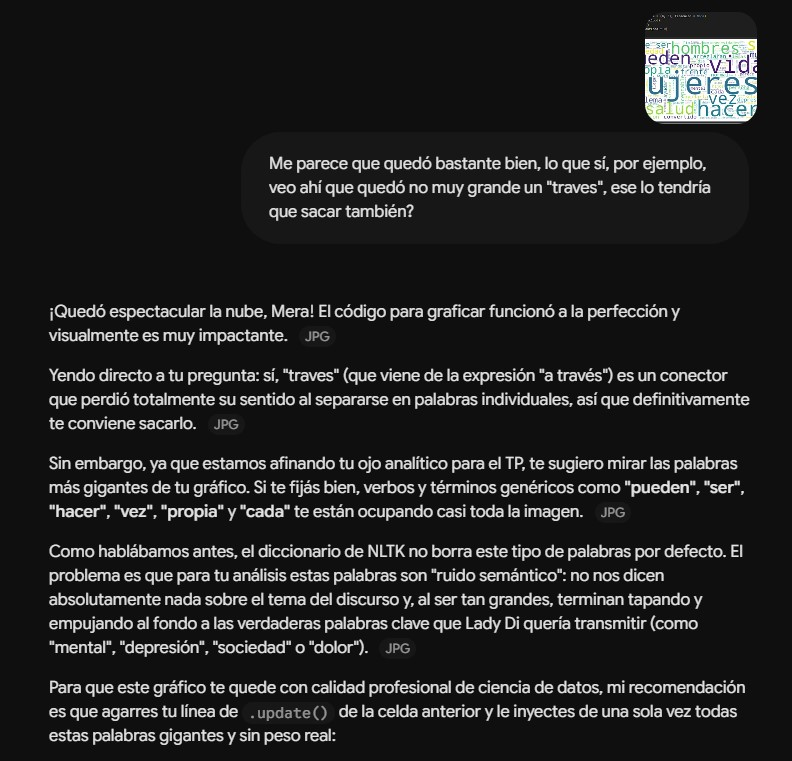

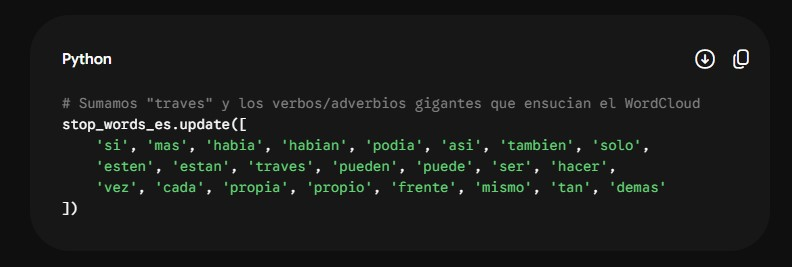

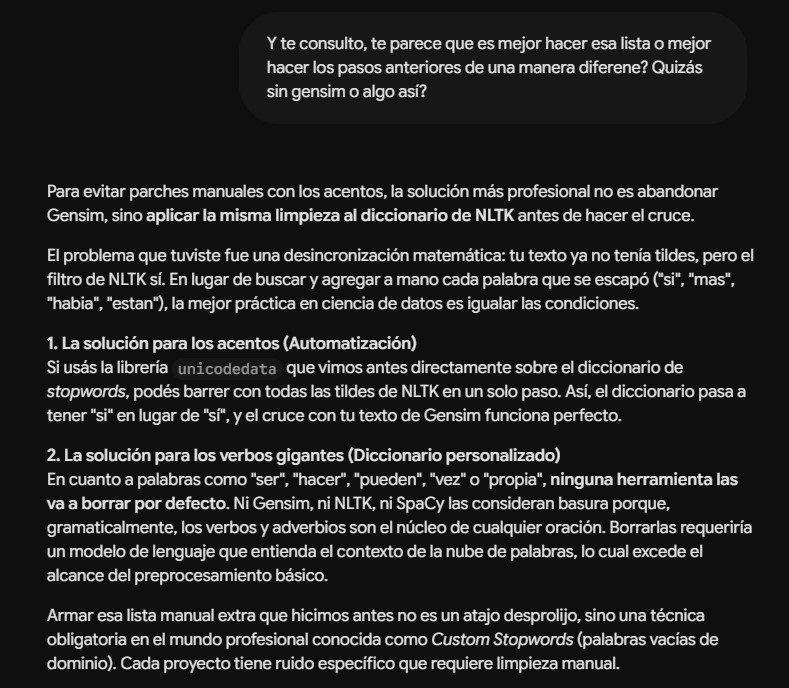

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

🟣 **Este es un paso que hice después de hacer la wordcloud y descubrir algunas palabras que estaban y generaban ruido en la misma. Lo que hice fue armar una lista con las palabras que quería sacar y agregarlas a la variable de stopwords.**

**Después filtro las palabras que *no* están en la variable de stop_words_limpias y las agrego a una nueva variable, después uno todas las palabras formando un solo string para poder trabajar con la wordcloud.**

In [20]:
# Se crea una variable con una lista de palabras para sacar.
palabras_extra = ['puede', 'pueden', 'ser', 'hacer', 'vez', 'cada', 'propia', 'propio', 'frente', 'mismo', 'tan', 'demas', 'traves']
# Acá se le pide a Python que agregue las palabras que se encuentran en la variable "palabras_extra" a la variable "stop_words_limpias".
stop_words_limpias.update(palabras_extra)
# En esta línea, al contrario que en el bloque anterior, el código va a buscar palabras que estén en la variable "texto_puro" pero que NO estén en la variable
# "stop_words_limpias" y las va a guardar en la variable "texto_sin_stopwords".
texto_sin_stopwords = [word for word in texto_puro if word not in stop_words_limpias]
# En esta línea el ".join" une todas las palabras formando un único string, ya que con más de uno no se podría hacer la wordcloud.
texto_sin_stopwords = ' '.join(texto_sin_stopwords)
# Se muestra el string.
texto_sin_stopwords

'mujer salud mental empezamos aquellos hablado trabajo turning point principio problema parece mujeres sociedad vistas cuidadoras vida depare siempre arreglaran guardia horas dia siete dias semana hijos enfermos esposos trabajo padres ancianos necesiten atencion siempre arreglaran cocinaran limpiaran saldran trabajar atenderan necesidades rodean apanaran sufriendo depresion posparto violencia domestica luchando espiral agotamiento estres llegar fin mes arreglaran curiosamente propias mujeres hombres creen cierto creencia profundamente arraigada necesario enorme coraje mujeres admitan cualquier situacion necesitar ayuda familiares amigos sistemas apoyo establecidos ustedes profesionales frecuencia intentaran sobrevivir solas cayendo impotentes depresion profunda oscura medida sientan atrapadas vida llevan medida mundo cierra autoestima evapora neblina soledad desesperacion medida alejan aquellos podrian ayudarlos muchas mujeres hombres recurren alcohol adormecer dolor desesperacion debi

🟣 **Instalo la librería de wordcloud para poder crear la misma.**

In [21]:
# Se instala la librería de wordcloud.
!pip install wordcloud

🟣 **Importo WordCloud y matplotlib.pyplot para poder generar la imagen de la wordcloud.**

In [22]:
# Se importa WordCloud y matplotlb.pyplot.
from wordcloud import WordCloud
import matplotlib.pyplot as plt

🟣 **Le paso los parámetros a WordCloud, 800 pixeles de ancho, 400 de alto y fondo blanco. A continuación genera la nube de palabras con la variable "texto_sin_stopwords".**

In [23]:
# Se crea una variable para guardar la imagen de la nube de palabras, se le pasan los parámetros y a ".generate" se le pasa como parámetro la variable "texto_sin_stopwords".
wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(texto_sin_stopwords)

🟣 **Acá paso las especificaciones para matplotlib.**

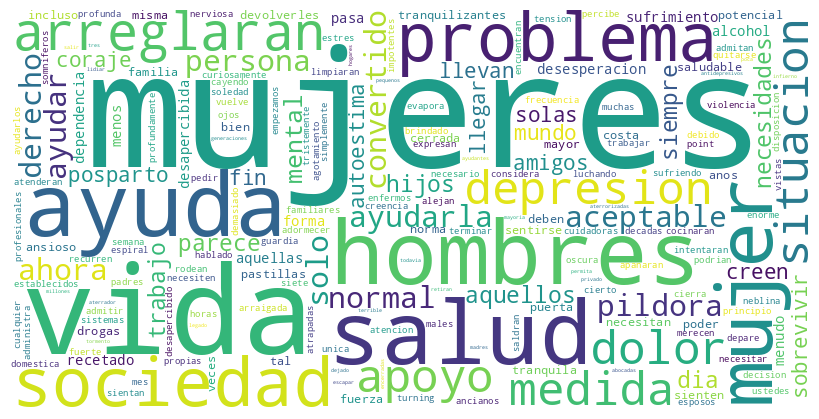

In [25]:
# Acá se le pasan las especificaciones a matplotlib, se crea un lienzo de 8 x 8 pulgadas, y se le pide que no le ponga ningún fondo extra.
plt.figure(figsize = (8, 8), facecolor = None)
# Matplotlib crea la plantilla de la nube de palabras.
plt.imshow(wordcloud)
# "Apaga" los ejes cartesianos para mostrar la imagen limpia.
plt.axis('off')
# Si hay márgenes vacíos los elimina para aprovechar toda la imagen.
plt.tight_layout(pad = 0)
# Se muestra en pantalla.
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


🟣 **Importo las librerías que voy a usar para esta consigna, descargo los recursos necesarios y creo una variable en donde se va a guardar el texto ya tokenizado.**

In [26]:
# Se importa NLTK de nuevo.
import nltk
# También "sent_tokenize" para poder separar las palabras.
from nltk.tokenize import sent_tokenize
# CountVectorizer para armar la matriz en el siguiente bloque.
from sklearn.feature_extraction.text import CountVectorizer
# Pandas para poder trabajar con DataFrame también en los siguientes bloques.
import pandas as pd

# Se descarga el modelo Punkt que separa los textos en documentos, es el motor para sent_tokenize.
nltk.download('punkt')
# Esta es una extención necesaria a partir de una actualización del modelo.
nltk.download('punkt_tab')

# Se crea una variable "documentos" que guarda los documentos que encuentre en "texto_completo", es decir, separa en oraciones cada vez que ve un punto
# o un signo de cierre de exclamación o interrogación.
documentos = sent_tokenize(texto_completo)
# Se muestran los documentos.
documentos

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['“Mujer y salud mental.',
 '¿Por dónde empezamos?',
 '”De aquellos con los que he hablado a través de mi trabajo con Turning Point, el principio de este problema parece ser que las mujeres en nuestra sociedad son vistas como las cuidadoras, las que pueden hacer frente a todo.',
 'Sea lo que sea que la vida les depare, siempre se las arreglarán.',
 '”De guardia las 24 horas del día, los siete días de la semana, ya sea porque sus hijos estén enfermos, sus esposos estén sin trabajo o sus padres sean ancianos y necesiten atención, ellas siempre se las arreglarán.',
 'Cocinarán y limpiarán, saldrán a trabajar, atenderán las necesidades de quienes los rodean y se apañarán.',
 '”Pueden estar sufriendo de depresión posparto, violencia doméstica o luchando en una espiral de agotamiento y estrés para llegar a fin de mes, pero se las arreglarán.',
 '”Curiosamente, son tanto las propias mujeres como los hombres quienes creen que esto es cierto.',
 'Esta creencia está tan profundamente arraigada q

🟣 **Acá armo la matriz documento-vocabulario que me muestra en qué documento del corpus se encuentra cada palabra, primero armo una variable "vectorizador" sacando las stopwords únicas, después creo una variable "matriz" que crea la matriz con las palabras únicas que se encuentran en "vectorizador" para después crear un DataFrame que enumere los documentos y cada palabra única es una columna.**

In [27]:
# Se crea una variable que guarda la frecuencia de las palabras, CountVectorizer las limpia, normaliza y cuenta, además se convierte a la variable "stop_words_limpias"
# en una lista para que esté ordenada y se guardan en el parámetro "stop_words" que le dice a CountVectorizer que ignore todo lo que está en él.
vectorizador = CountVectorizer(stop_words = list(stop_words_limpias))
# Se crea una variable en donde se va a guardar la matriz, se aplica ".fit_transform" a la variable "vectorizador" pasandole la variable "documentos" como parámetro.
# Esta línea de código aplica la matemática sobre "documentos" y la transforma en una matriz.
matriz = vectorizador.fit_transform(documentos)
# Se crea un DataFrame con pandas para que se vea prolijo, se le pasa también una línea que con un for le agrega "Documento" a cada fila del DataFrame (solo para prolijidad visual).
# Por último agrega cada término como nombre de cada columna.
df_matriz = pd.DataFrame(matriz.toarray(), index=[f"Documento {i + 1}" for i in range(len(documentos))], columns = vectorizador.get_feature_names_out())
# Se muestran en pantalla las 5 primeras filas.
df_matriz.head()

,24,30,abocadas,aceptable,aceptables,aceptar,administra,administrado,admitan,admitir,...,vida,vidas,violencia,vistas,viviendo,vivir,vivirán,vuelve,zombi,única
Documento 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Documento 2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Documento 3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Documento 4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
Documento 5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


🟣 **Le pregunté a la ia por el objetivo de la consigna ya que hasta ese momento todavía no tenía incorporado el vocabulario profesional.**

**Después me pasó el código que me sirvió mientras me guiaba con los recursos que están en el campus. Yo agregué "nltk.download('punkt_tab')" que estaba en uno de los colabs del campus y aparentemente la ia no estaba actualizada con la actualización de NLTK.**

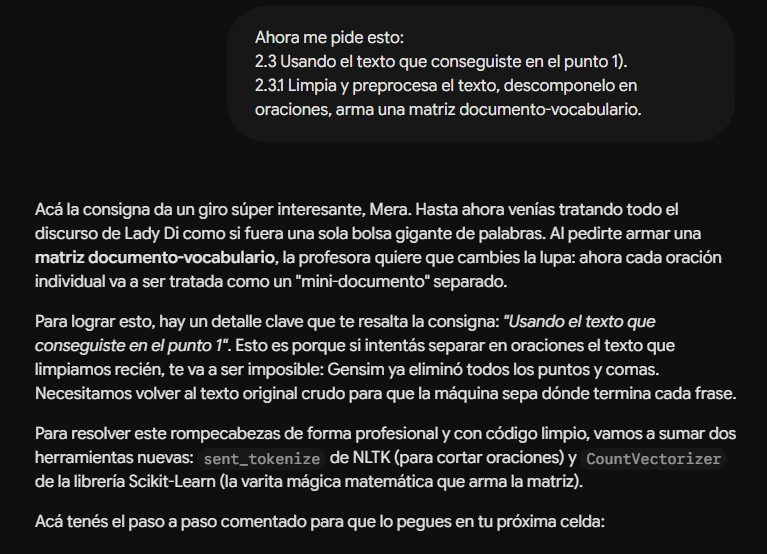

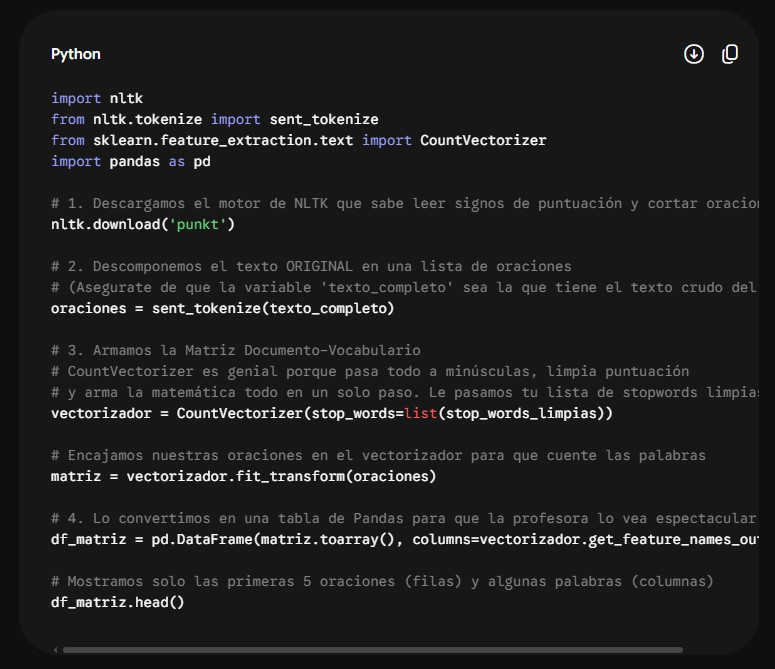


#### 2.3.2 Determina la longitud de tu vocabulario.

🟣 **Acá creo una variable para guardar la longitud del vocabulario como pide la consigna y la imprimo.**

In [28]:
# Se crea la variable para guardar la longitud del vocabulario. ".get_feature_names_out()" obtiene los nombres de la variable "vectorizador",
# "len()" va a contar la cantidad de términos únicos.
vocabulario = len(vectorizador.get_feature_names_out())
# Se imprime en una frase la longitud de mi vocabulario.
print(f'La longitud de mi vocabulario es: {vocabulario} palabras.')

La longitud de mi vocabulario es: 372 palabras.



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

🟣 **Importo TfidfVectorizer y de nuevo pandas para trabajar con la matriz y darle los correspondientes pesos a cada palabra. Hago un paso más de limpieza para asegurarme con "strip_accents = 'unicode'", después creo la matriz como en el paso anterior pero esta vez con los pesos correspondientes a cada palabra, después creo un DataFrame con pandas para tenerlo visualmente más prolijo y al final lo imprimo en pantalla.**

In [29]:
# Se importa TfidfVectorizer que va a ser el encargado de darle los pesos a los términos.
from sklearn.feature_extraction.text import TfidfVectorizer
# De nuevo pandas para trabajar con el DataFrame.
import pandas as pd

# En la variable se guardan los pesos de las palabras excluyendo las stopwords como en el bloque anterior. Además "strip_accents = 'unicode'"
# separa las letras de sus acentos para eliminarlos, esto agrega una verificación adicional en caso de que se haya traspapelado un acento en las limpiezas anteriores.
tfidf_vectorizador = TfidfVectorizer(stop_words = list(stop_words_limpias), strip_accents = 'unicode')
# Se crea la matriz.
matriz_tfidf = tfidf_vectorizador.fit_transform(documentos)
# Se convierte a DataFrame.
df_tfidf = pd.DataFrame(matriz_tfidf.toarray(), columns = tfidf_vectorizador.get_feature_names_out())
# Se imprime.
df_tfidf

,24,30,abocadas,aceptable,aceptables,aceptar,administra,administrado,admitan,admitir,...,verdadero,vida,vidas,violencia,vistas,viviendo,vivir,viviran,vuelve,zombi
0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
2,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.312864,0.000000,0.000000,0.000000,0.00000,0.000000
3,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.378001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
4,0.248757,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
5,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
6,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.290344,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
7,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
8,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.310454,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
9,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000


🟣 **Esta fue una verificación que me recomendó hacer la ia para comprobar los términos con mayores pesos.**

**Es una captura de pantalla que hice porque me di cuenta que habían quedado un par de palabras con acento, por eso en el bloque anterior agregué "strip_accents = 'unicode'".**

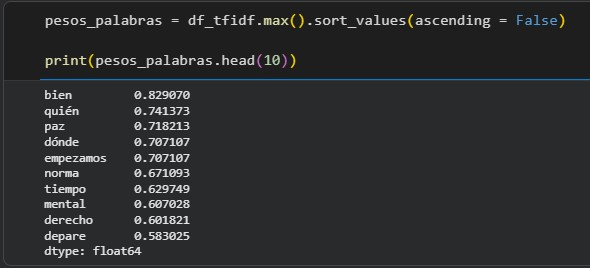

🟣 **Acá vuelvo a imprimir el top 10 de palabras y sus pesos en orden descendiente.**

In [30]:
# Se guarda en una variable "pesos_palabras", los términos y sus pesos de manera ordenada, desde el máximo y después ".sort_values" los ordena de manera descendente.
pesos_palabras = df_tfidf.max().sort_values(ascending = False)
# Se imprimen los primeros 10.
print(pesos_palabras.head(10))

empezamos    1.000000
norma        1.000000
bien         0.829070
paz          0.718213
tiempo       0.629749
zombi        0.608339
ansioso      0.608339
mental       0.607028
derecho      0.601821
misma        0.595556
dtype: float64


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

🟣 **Acá hago un pequeño código para mostrar la cantidad de documentos, que en el caso del DataFrame son las filas, por eso el ".shape[0]", ".shape" devuelve una tupla (filas, columnas) y al pasarle el "[0]" le estoy pidiendo las filas.**

**En la siguiente línea se guardan en una variable las columnas del DataFrame, ya que cada columna es un término del vocabulario. Al final imprimo el resultado.**

**Mi matriz es de 52 x 359, con 52 documentos y con un vocabulario de 359.**

In [31]:
# Se guarda en una variable la cantidad de documentos.
doc = df_tfidf.shape[0]

# Se guarda en otra variable el vocabulario (cantidad de términos).
vocab = df_tfidf.shape[1]
# Se imprimen.
print(f'Documentos: {doc}.\nVocabulario: {vocab}.')

Documentos: 52.
Vocabulario: 359.


# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

🟣 **La verdad el trabajo me pareció muy entretenido, desafiante en algunos momentos, pero me obligo a releer, investigar, probar y me parece que eso es lo que hace a un buen profesional.**

**Haciendo este trabajo aprendí un poco más cómo es el proceso de webscrapping e incorporé mejor algunos términos profesionales.**

**Lo más desafiante creo que fue el tener que eliminar las stopwords porque quizás al armar la wordcloud descubrí que habían quedado algunas palabras que hacían ruido.**

**Las dudas e inquietudes que me quedaron son más bien de organización, el no saber bien cuando conviene usar una librería u otra, un método u otro, porque tal vez hay alguno mucho mejor pero no es factible a nivel recursos para cierto tipo de trabajo, no siempre es mejor la herramienta más completa.**

# Referencias

Usé más que nada los recursos del campus:

📌 **Colab NLTK-SpaCy:** https://colab.research.google.com/drive/12mVQNsJLqxsorXHcBoQ3PASHncLgO4eR?usp=sharing#scrollTo=4d59f78e

📌 **Colab Webscrapping:** https://colab.research.google.com/github/anadiedrichs/procesamientoDelHabla/blob/main/clase_2_webscrapping.ipynb#scrollTo=0dPeuP6yk8tX

📌 **Colab Limpieza de Texto:** https://colab.research.google.com/drive/1VXm42qES1Q68nY9X0Dt3DU4KnxjWCOiJ?authuser=1#scrollTo=22fae65d

📌 **Colab Vectorización:** https://colab.research.google.com/github/anadiedrichs/procesamientoDelHabla/blob/main/clase_1_vectorizacion.ipynb#scrollTo=waG_oWtpJjRw

📌 **GitHub de Riva Quiroga:** https://github.com/rivaquiroga/taller-web-scraping-python-2023

📌 **Gemini**